# SystemicRisk Net (EDA)

In [48]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
from scipy.stats import norm, kurtosis, skew
import seaborn as sns

## Extreme events analysis

In [41]:
tickers1 = ['AAPL']
data1 = yf.download(tickers1, period="1y")['Close']

# 2. Cálculo de retornos logarítmicos: $r_t = \ln(P_t / P_{t-1})$
returns = np.log(data1 / data1.shift(1)).dropna()

# 3. Cálculo de métricas de eventos extremos
for ticker in tickers1:
    s = skew(returns[ticker])
    k = kurtosis(returns[ticker]) # Kurtosis > 3 indica caudas pesadas
    print(f"{ticker} -> Skewness: {s:.2f}, Kurtosis (excesso): {k:.2f}")


fig = px.histogram(returns, 
                   x=returns.columns, 
                   marginal="rug", 
                   histnorm='probability density',
                   nbins=100,
                   barmode='overlay',
                   title="Tail Analysis: Real Returns vs. Normal")


for col in returns.columns:
    x_range = np.linspace(returns[col].min(), returns[col].max(), 100)
    y_normal = norm.pdf(x_range, returns[col].mean(), returns[col].std())
    
    fig.add_trace(go.Scatter(x=x_range, y=y_normal, 
                             mode='lines', 
                             name=f'Normal {col}',
                             line=dict(dash='dash')))

fig.update_layout(xaxis_title="Logaritmic Return ($r_t$)", 
                  yaxis_title="Density",
                  template="plotly_white")
fig.show()

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_6125/824362074.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

AAPL -> Skewness: 0.74, Kurtosis (excesso): 12.30


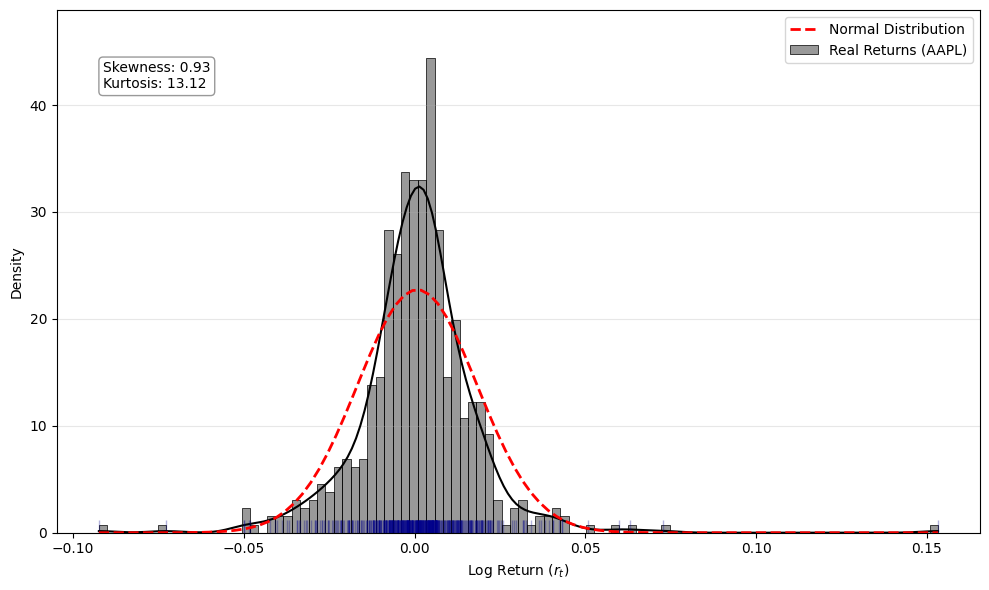

In [54]:
plt.figure(figsize=(10, 6))

# 2. Histograma e Densidade Real (KDE)
# O Seaborn facilita muito a criação do rug plot e da densidade num só passo
sns.histplot(returns['AAPL'], kde=True, stat="density", bins=100, 
             color='black', alpha=0.4, label='Real Returns (AAPL)')

# 3. Rug Plot (os traços na base para identificar Extreme Events)
sns.rugplot(returns['AAPL'], color='darkblue', alpha=0.3)

# 4. Curva Normal Teórica para comparação
x = np.linspace(returns['AAPL'].min(), returns['AAPL'].max(), 100)
y = norm.pdf(x, returns['AAPL'].mean(), returns['AAPL'].std())
plt.plot(x, y, 'r--', lw=2, label='Normal Distribution')

# 5. Estética e Títulos

plt.xlabel('Log Return ($r_t$)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar métricas no gráfico (opcional, mas bom para a EDA)
textstr = f'Skewness: {skew(returns["AAPL"]):.2f}\nKurtosis: {kurtosis(returns["AAPL"]):.2f}'
plt.gca().annotate(textstr, xy=(0.05, 0.85), xycoords='axes fraction', 
                   bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

With values of Kurtosis of 20, we can see that these tickers do not follow a normal distribution, and while having the shape of one, they have fat tails -> great probabilities of a extreme event. And what is most importante is that with a kurtosis of > 8, most coventional tools to model volatility fail. We think that a nice visual tool can be important

In [42]:
confidence_levels = [0.95, 0.99]

for ticker in returns.columns:
    print(f"\n--- Métricas de Risco: {ticker} ---")
    
    for cl in confidence_levels:
        # 1. VaR Histórico (Não assume distribuição, usa os dados reais)
        var_historic = np.percentile(returns[ticker], (1 - cl) * 100)
        
        # 2. VaR Paramétrico (Assume distribuição normal)
        # Nota: Com Kurtosis de 8.16, este valor será menos preciso que o Histórico
        var_parametric = norm.ppf(1 - cl, returns[ticker].mean(), returns[ticker].std())
        
        print(f"Confiança {cl*100}%:")
        print(f"  VaR Histórico: {var_historic:.2%}")
        print(f"  VaR Paramétrico: {var_parametric:.2%}")


--- Métricas de Risco: AAPL ---
Confiança 95.0%:
  VaR Histórico: -3.24%
  VaR Paramétrico: -3.29%
Confiança 99.0%:
  VaR Histórico: -5.12%
  VaR Paramétrico: -4.66%


In [45]:
spy_eme = returns[returns['AAPL'] < returns['AAPL'].quantile(0.01)]

print("Extreme event dates (Top 1% losses):")
print(spy_eme['AAPL'].sort_values().head(10))

Extreme event dates (Top 1% losses):
Date
2025-04-03   -0.097013
2025-04-04   -0.075680
2026-02-12   -0.051274
Name: AAPL, dtype: float64


In [46]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'GS', 'XOM', 'CVX', 'SPY']
data = yf.download(tickers, start="2024-01-01", end="2026-02-15")['Close']
returns = data.pct_change().dropna()

# 2. Definir a Janela de Stress (Abril 2025)
# Pegamos em 15 dias antes e depois do evento para ver o contágio
stress_window = returns.loc['2025-03-20':'2025-04-15']

# 3. Definir a Janela de Calma (Ex: Outubro 2024)
# Escolhemos um período onde o SPY teve baixa volatilidade
calm_window = returns.loc['2024-10-01':'2024-10-31']

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_6125/3569094416.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  8 of 8 completed


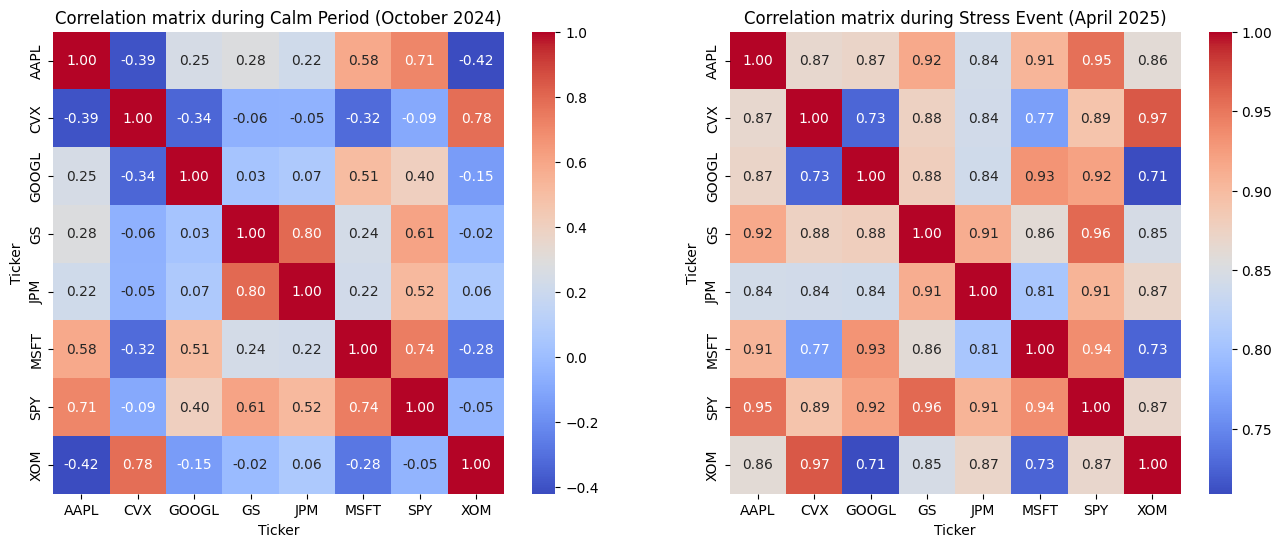

In [55]:
corr_stress = stress_window.corr()
corr_calm = calm_window.corr()

# Visualização Comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_calm, annot=True, cmap='coolwarm', fmt=".2f", ax=ax1)
ax1.set_title('Correlation matrix during Calm Period (October 2024)')

sns.heatmap(corr_stress, annot=True, cmap='coolwarm', fmt=".2f", ax=ax2)
ax2.set_title('Correlation matrix during Stress Event (April 2025)')

plt.show()

In [56]:
# Supondo que tens os DataFrames das matrizes que geraram as imagens
matriz_paz = corr_calm
matriz_guerra = corr_stress

# Calcular o salto de correlação
matriz_contagio = matriz_guerra - matriz_paz

# No relatório, destaca os maiores saltos
print("Maiores quebras de diversificação (Saltos de correlação):")
print(matriz_contagio.unstack().sort_values(ascending=False).drop_duplicates().head(10))

Maiores quebras de diversificação (Saltos de correlação):
Ticker  Ticker
XOM     AAPL      1.282206
AAPL    CVX       1.260943
MSFT    CVX       1.088109
GOOGL   CVX       1.065493
MSFT    XOM       1.003468
CVX     SPY       0.981417
GS      CVX       0.934914
SPY     XOM       0.914371
JPM     CVX       0.896061
XOM     GS        0.862168
dtype: float64


In [57]:
geo_proxies = {
    'AAPL': 'Apple (USA)',
    'MCHI': 'China',
    'EWT': 'Taiwan',
    'EWG': 'Germany',
    'EWJ': 'Japan',
    'EWW': 'Mexico'
}

# 2. Download dos dados (focando no período de Abril de 2025) [cite: 29]
data_geo = yf.download(list(geo_proxies.keys()), start="2025-03-01", end="2025-05-01")['Close']
returns_geo = data_geo.pct_change().dropna()

# 3. Matriz de correlação durante o evento de tarifas (Abril 2025)
# Aqui vês o "Asset Contagion" em ação [cite: 18]
stress_corr = returns_geo.corr()

# Isolar a correlação da Apple com o resto do mundo
aapl_impact = stress_corr['AAPL'].sort_values(ascending=False)
print("Correlação da AAPL com Economias Globais (Stress de Abril):")
print(aapl_impact)

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_6125/1951554921.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  6 of 6 completed

Correlação da AAPL com Economias Globais (Stress de Abril):
Ticker
AAPL    1.000000
EWT     0.878406
EWJ     0.845988
EWG     0.811529
MCHI    0.651512
EWW     0.581996
Name: AAPL, dtype: float64


In [58]:
import yfinance as yf
import pandas as pd

# 1. Mesmos ativos geográficos para comparação direta
geo_proxies = {
    'AAPL': 'Apple (USA)',
    'MCHI': 'China',
    'EWT': 'Taiwan',
    'EWG': 'Germany',
    'EWJ': 'Japan',
    'EWW': 'Mexico'
}

# 2. Download dos dados num período de "Paz" (Outubro 2024)
data_calm = yf.download(list(geo_proxies.keys()), start="2024-10-01", end="2024-11-01")['Close']
returns_calm = data_calm.pct_change().dropna()

# 3. Matriz de correlação em período estável
calm_corr = returns_calm.corr()

# 4. Isolar a correlação da Apple
aapl_calm = calm_corr['AAPL'].sort_values(ascending=False)

print("Correlação da AAPL em Período de Paz (Outubro 2024):")
print(aapl_calm)

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_6125/4273747225.py:15: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  6 of 6 completed

Correlação da AAPL em Período de Paz (Outubro 2024):
Ticker
AAPL    1.000000
EWG     0.557015
EWJ     0.255210
EWT     0.214777
EWW    -0.002675
MCHI   -0.340789
Name: AAPL, dtype: float64


/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_6125/1817465269.py:13: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  6 of 6 completed


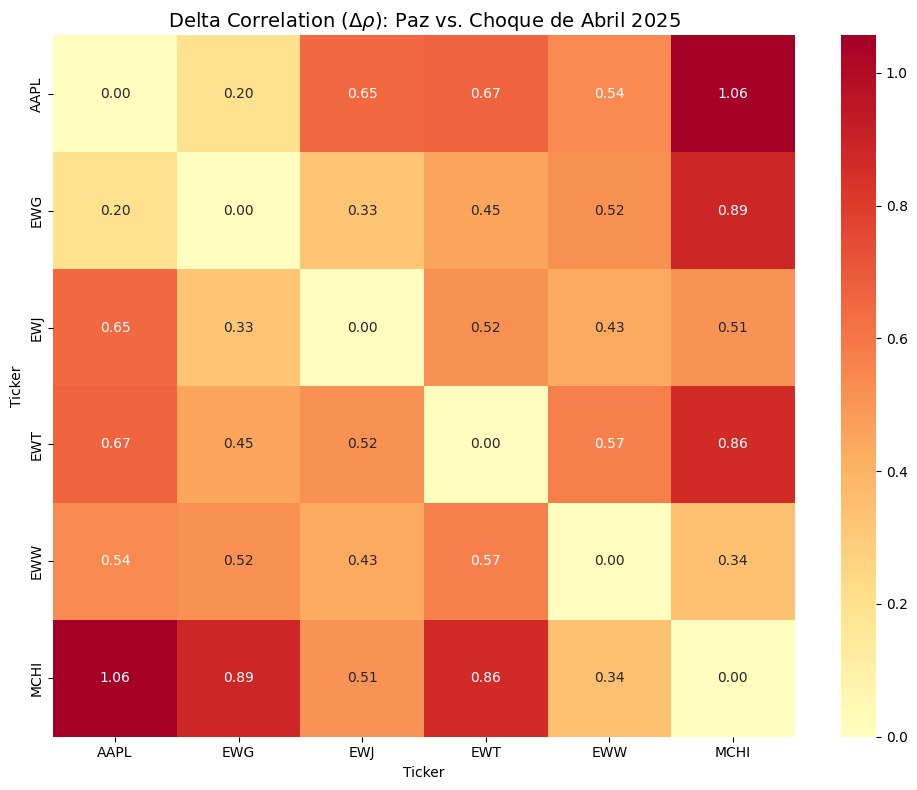

Maiores saltos de correlação (Contágio Crítico):
Ticker  Ticker
MCHI    AAPL      1.056614
EWG     MCHI      0.886016
MCHI    EWT       0.861713
EWT     AAPL      0.665453
AAPL    EWJ       0.651034
EWT     EWW       0.570138
EWW     AAPL      0.538072
EWG     EWW       0.518514
EWT     EWJ       0.517714
EWJ     MCHI      0.510534
dtype: float64


In [60]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuração de ativos e períodos
tickers = ['AAPL', 'MCHI', 'EWT', 'EWG', 'EWJ', 'EWW']
paz_period = ("2024-10-01", "2024-11-01")
stress_period = ("2025-03-01", "2025-05-01")

# 2. Download e Cálculo de Log-Returns (consistente com a tua fórmula)
data = yf.download(tickers, start="2024-09-01", end="2025-06-01")['Close']
returns = np.log(data / data.shift(1)).dropna()

# 3. Cálculo das Matrizes
corr_paz = returns.loc[paz_period[0]:paz_period[1]].corr()
corr_stress = returns.loc[stress_period[0]:stress_period[1]].corr()

# 4. Cálculo do Delta (O Contágio Puro)
delta_corr = corr_stress - corr_paz

# 5. Visualização
plt.figure(figsize=(10, 8))
sns.heatmap(delta_corr, annot=True, cmap='RdYlGn_r', center=0, fmt=".2f")
plt.title(r'Delta Correlation ($\Delta \rho$): Paz vs. Choque de Abril 2025', fontsize=14)
plt.tight_layout()
plt.show()

# Export para o teu relatório: Maiores aumentos de contágio
print("Maiores saltos de correlação (Contágio Crítico):")
print(delta_corr.unstack().sort_values(ascending=False).drop_duplicates().head(10))